## **Evaluation**

In [1]:
import os
import torch
from model.evaluation import evaluate_bleu
from model.generation import image_caption
from model.trainer import  flick , vocab_size
from model.model import encoder_decoder
from model.trainer import test_dataset

device = "cuda"  if torch.cuda.is_available() else "cpu"

model=encoder_decoder(em_size=712,
                            hidden_size=712,
                            expand_scale=2,
                            vocab_size=vocab_size,
                            num_expert=3,
                            max_length=1000,
                            num_head=8,
                            head_dim=712,
                            num_layers=4,
                            dropout_size=0.2
                      ).to(device)


# loading the checkpoint
if os.path.exists(f"checkpoints/checkpoint_9.pth"):
    checkpoint = torch.load(f"checkpoints/checkpoint_9.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

print("\n the model loaded \n\n")
print("*Evaluation*: \n")

bl1,bl4=evaluate_bleu(model, test_dataset, flick, device="cuda", max_examples=None)

print(f'bl1:{bl1}')
print(f'bl4:{bl4}')





 the model loaded 


*Evaluation*: 

The early layer  for the token : [two] is : the Layer [-1] and it's exit probability is [0.596315860748291] 
The early layer  for the token : [men] is : the Layer [-1] and it's exit probability is [0.4868146479129791] 
The early layer  for the token : [are] is : the Layer [-1] and it's exit probability is [0.35280007123947144] 
The early layer  for the token : [posing] is : the Layer [-1] and it's exit probability is [0.2951309382915497] 
The early layer  for the token : [on] is : the Layer [-1] and it's exit probability is [0.5848696827888489] 
The early layer  for the token : [a] is : the Layer [-1] and it's exit probability is [0.6306313872337341] 
The early layer  for the token : [<UNK>] is : the Layer [-1] and it's exit probability is [0.5089805722236633] 
The early layer  for the token : [in] is : the Layer [-1] and it's exit probability is [0.420134961605072] 
The early layer  for the token : [front] is : the Layer [-1] and it's exit probabi

## **Testing the model**

The early layer  for the token : [a] is : the Layer [-1] and it's exit probability is [0.7975594997406006] 
The early layer  for the token : [man] is : the Layer [-1] and it's exit probability is [0.5247838497161865] 
The early layer  for the token : [in] is : the Layer [-1] and it's exit probability is [0.30593475699424744] 
The early layer  for the token : [black] is : the Layer [-1] and it's exit probability is [0.7333465218544006] 
The early layer  for the token : [shorts] is : the Layer [-1] and it's exit probability is [0.5471649765968323] 
The early layer  for the token : [and] is : the Layer [-1] and it's exit probability is [0.4311791658401489] 
The early layer  for the token : [no] is : the Layer [-1] and it's exit probability is [0.7127312421798706] 
The early layer  for the token : [shirt] is : the Layer [-1] and it's exit probability is [0.6973692178726196] 
The early layer  for the token : [is] is : the Layer [-1] and it's exit probability is [0.3603244423866272] 
The ear

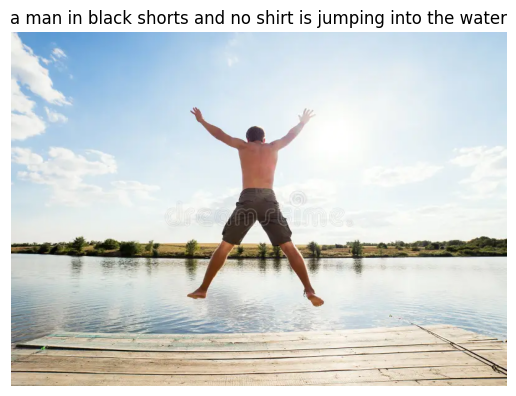

a man in black shorts and no shirt is jumping into the water


In [2]:
print(image_caption(model=model,full_image_path='test_images/shdflhfkdsfhlk.png',vocab=flick.vocab.W2i,max_length=40))


In [3]:
print(f"The number of trained parameters {sum(p.numel() for p in model.parameters() if p.requires_grad)} ")



The number of trained parameters 186900663 
